## Systemy Sztucznej Inteligencji - Hubert Kiszka
**Cel projektu:** Przewidywanie wyniku kierowcy w wyścigu F1 (Podium/Punkty/Poza punktami) oraz system ekspercki z logiką rozmytą doradzający w kwesti strategii pit stopów.

In [ ]:
# Instalacja potrzebnych bibliotek
# !pip install scikit-fuzzy torch pandas numpy scikit-learn matplotlib seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, ConfusionMatrixDisplay
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import warnings
warnings.filterwarnings("ignore")

## 1. Przygotowanie danych
Zbiór danych: **Formula 1 World Championship (1950-2024) - Kaggle**
Ze zbioru wartości wybieramy pliki: `results.csv`, `races.csv`, `drivers.csv`, `constructors.csv`, `qualifying.csv`

Rozmiary zbiorów:
results:      (26759, 18)
races:        (1125, 18)
drivers:      (861, 9)
constructors: (212, 5)
qualifying:   (10494, 9)
       resultId  raceId  driverId  constructorId number  grid position  \
0             1      18         1              1     22     1        1   
1             2      18         2              2      3     5        2   
2             3      18         3              3      7     7        3   
3             4      18         4              4      5    11        4   
4             5      18         5              1     23     3        5   
...         ...     ...       ...            ...    ...   ...      ...   
26754     26760    1144       825            210     20    14       16   
26755     26761    1144       859            215     30    12       17   
26756     26762    1144       822             15     77     9      NaN   
26757     26763    1144       861              3     43    20      NaN   
26758     26764    1144       815             

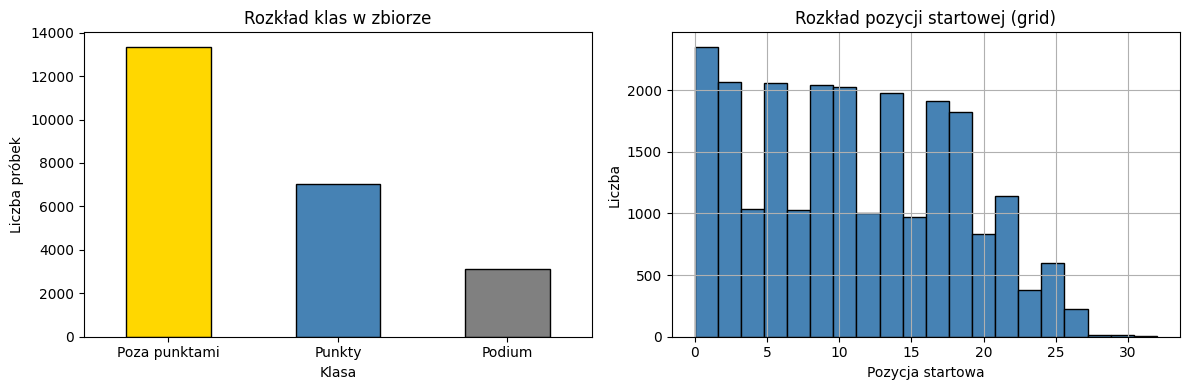

In [22]:
results = pd.read_csv('data/results.csv')
races = pd.read_csv('data/races.csv')
drivers = pd.read_csv('data/drivers.csv')
constructors = pd.read_csv('data/constructors.csv')
qualifying = pd.read_csv('data/qualifying.csv')
driver_standings = pd.read_csv('data/driver_standings.csv')
constructor_standings = pd.read_csv('data/constructor_standings.csv')

print('Rozmiary zbiorów:')
print(f'results:      {results.shape}')
print(f'races:        {races.shape}')
print(f'drivers:      {drivers.shape}')
print(f'constructors: {constructors.shape}')
print(f'qualifying:   {qualifying.shape}')

df = results.merge(races[['raceId', 'year', 'circuitId', 'round']], on='raceId')
df = df.merge(drivers[['driverId', 'nationality']], on='driverId')
df = df.merge(constructors[['constructorId', 'nationality']], on='constructorId', suffixes=('_driver', '_constructor'))
df = df.merge(qualifying[['raceId', 'driverId', 'position']].rename(columns={'position': 'grid_quali'}),on=['raceId', 'driverId'],how='left')
df.replace('\\N', np.nan, inplace=True)
cols_numeric = ['positionOrder', 'grid', 'laps', 'points', 'milliseconds', 'fastestLapSpeed', 'grid_quali']
for col in cols_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Usunięcie wierszy bez pozycji końcowej
df = df.dropna(subset=['positionOrder'])
print(df)
print("====================================")
# 3 klasy: Podium (1-3), Punkty (4-10), Poza punktami (>=11)
def classify_result(pos):
    if pos <= 3:
        return 'Podium'
    elif pos <= 10:
        return 'Punkty'
    else:
        return 'Poza punktami'

df['target'] = df['positionOrder'].apply(classify_result)
print(df['target'].value_counts())

# Uzupełnienie brakujących wartości
df['grid_quali'] = df['grid_quali'].fillna(df['grid'])
df = df.sort_values(['year', 'round'])
df['avg_grid_season'] = df.groupby(['year', 'driverId'])['grid'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df['avg_position_season'] = df.groupby(['year', 'driverId'])['positionOrder'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df['avg_constructor_season'] = df.groupby(['year', 'constructorId'])['positionOrder'].transform(
    lambda x: x.expanding().mean().shift(1)
)
# Pozycja w mistrzostwach przed wyścigiem
ds = driver_standings.merge(races[['raceId', 'year', 'round']], on='raceId')
ds = ds.sort_values(['driverId', 'year', 'round'])
ds['driver_pos_before_race'] = ds.groupby(['driverId', 'year'])['position'].shift(1).fillna(20)
df = df.merge(ds[['raceId', 'driverId', 'driver_pos_before_race']], on=['raceId', 'driverId'], how='left')
df['driver_pos_before_race'] = df['driver_pos_before_race'].fillna(20)

# Pozycja konstruktora w mistrzostwach przed wyścigiem
cs = constructor_standings.merge(races[['raceId', 'year', 'round']], on='raceId')
cs = cs.sort_values(['constructorId', 'year', 'round'])
cs['constructor_pos_before_race'] = cs.groupby(['constructorId', 'year'])['position'].shift(1).fillna(10)
df = df.merge(cs[['raceId', 'constructorId', 'constructor_pos_before_race']], on=['raceId', 'constructorId'], how='left')
df['constructor_pos_before_race'] = df['constructor_pos_before_race'].fillna(10)

# Historia kierowcy na danym torze
df = df.sort_values(['driverId', 'circuitId', 'year'])
df['hist_track_avg'] = df.groupby(['driverId', 'circuitId'])['positionOrder'].transform(
    lambda x: x.expanding().mean().shift(1)
)
df['hist_track_avg'] = df['hist_track_avg'].fillna(15)
df = df.sort_values(['year', 'round'])

# Wybór cech do modelu
FEATURES = [
    'grid',
    'grid_quali',
    'avg_grid_season',
    'avg_position_season',
    'avg_constructor_season',
    'driver_pos_before_race',
    'constructor_pos_before_race',
    'hist_track_avg',
]
X = df[FEATURES].copy()
y = df['target'].copy()
print(X)

# Usunięcie wierszy z NaN w cechach
mask = X.notna().all(axis=1)
X, y = X[mask], y[mask]
print(f'Zbiór: {X.shape[0]} próbek, {X.shape[1]} cech')

# Podział na zbiory
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Skalowanie wartości dla SVM i KNN
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Trening: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# Wizualizacja rozkładu klas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y.value_counts().plot(kind='bar', ax=axes[0], color=['gold', 'steelblue', 'gray'], edgecolor='black')
axes[0].set_title('Rozkład klas w zbiorze')
axes[0].set_xlabel('Klasa')
axes[0].set_ylabel('Liczba próbek')
axes[0].tick_params(axis='x', rotation=0)
X['grid'].hist(ax=axes[1], bins=20, color='steelblue', edgecolor='black')
axes[1].set_title('Rozkład pozycji startowej (grid)')
axes[1].set_xlabel('Pozycja startowa')
axes[1].set_ylabel('Liczba')
plt.tight_layout()
plt.savefig('plots/01_data_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Analiza anomalii

Wykorzystano `IsolationForest` do wykrycia i izolacji wartości odstających. W zbiorze występuje 940 anomalii, natomiast w opracowywanym przypadku nie ma sensu usuwania ich ze zbioru ponieważ są to wyścigowe zdarzenia - kolizje, awarie, czerwone flagi, SC, VSC - które model powinien umieć obsłużyć. Przez usunięcie ich model nie nauczy się, że np. kierowca startujący z pole position może być DNF

In [3]:
iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso.fit_predict(X_train_sc)

# -1 = anomalia, 1 = normalna obserwacja
n_anomalies = (anomaly_labels == -1).sum()
print(f'Wykryte anomalie: {n_anomalies} ({n_anomalies/len(anomaly_labels)*100:.1f}% zbioru treningowego)')

Wykryte anomalie: 940 (5.0% zbioru treningowego)


In [23]:
brazil_2024 = df[df['raceId'] == 1141].copy()
verstappen = brazil_2024[brazil_2024['driverId'] == 830]
print(verstappen[['driverId', 'grid', 'positionOrder', 'points', 'laps', 'target']])

       driverId  grid  positionOrder  points  laps  target
26679       830    17              1    26.0    69  Podium


## 3. Budowa Random Forest
### 3.1 Model bazowy + ocena


=== Random Forest (bazowy) ===
Accuracy:        0.6285
F1 (weighted):   0.6147
CV Accuracy (5): 0.6267
               precision    recall  f1-score   support

       Podium       0.56      0.56      0.56       622
Poza punktami       0.69      0.79      0.74      2670
       Punkty       0.48      0.35      0.40      1408

     accuracy                           0.63      4700
    macro avg       0.58      0.57      0.57      4700
 weighted avg       0.61      0.63      0.61      4700



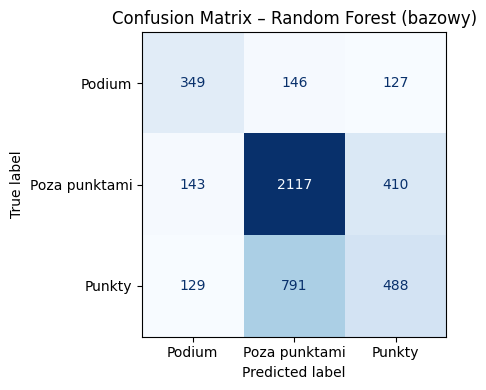

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='weighted')
    cv  = cross_val_score(model, X_tr, y_tr, cv=5, scoring='accuracy').mean()
    print(f'\n=== {name} ===')
    print(f'Accuracy:        {acc:.4f}')
    print(f'F1 (weighted):   {f1:.4f}')
    print(f'CV Accuracy (5): {cv:.4f}')
    print(classification_report(y_te, y_pred))
    _, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix – {name}')
    plt.tight_layout()
    plt.savefig(f'plots/cm_{name.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()
    return model, acc, f1

rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base, rf_acc, rf_f1 = evaluate_model(
    'Random Forest (bazowy)', rf_base,
    X_train, y_train,
    X_test, y_test
)

### 3.2 Kalibracja RandomForest - GridSearchCV

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Najlepsze parametry RF: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Najlepsza CV accuracy:  0.6441

=== Random Forest (po kalibracji) ===
Accuracy:        0.6370
F1 (weighted):   0.6220
CV Accuracy (5): 0.6441
               precision    recall  f1-score   support

       Podium       0.56      0.60      0.58       622
Poza punktami       0.70      0.80      0.75      2670
       Punkty       0.49      0.34      0.40      1408

     accuracy                           0.64      4700
    macro avg       0.58      0.58      0.58      4700
 weighted avg       0.62      0.64      0.62      4700



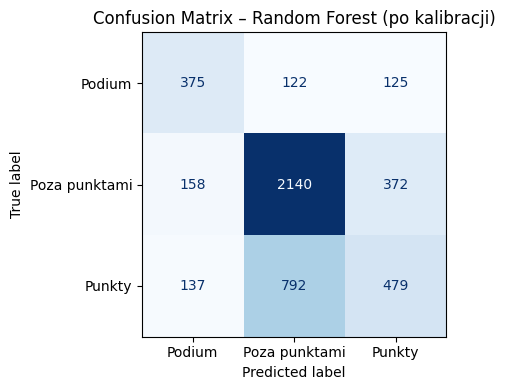

In [6]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)
print(f'\nNajlepsze parametry RF: {grid_rf.best_params_}')
print(f'Najlepsza CV accuracy:  {grid_rf.best_score_:.4f}')
rf_best = grid_rf.best_estimator_
rf_best, rf_acc, rf_f1 = evaluate_model(
    'Random Forest (po kalibracji)', rf_best,
    X_train, y_train,
    X_test, y_test
)

##  4. Budowa Support Vector Machine
### 4.1 Model bazowy + ocena


=== SVM (bazowy) ===
Accuracy:        0.6360
F1 (weighted):   0.6101
CV Accuracy (5): 0.6447
               precision    recall  f1-score   support

       Podium       0.58      0.58      0.58       622
Poza punktami       0.68      0.84      0.75      2670
       Punkty       0.48      0.28      0.35      1408

     accuracy                           0.64      4700
    macro avg       0.58      0.56      0.56      4700
 weighted avg       0.61      0.64      0.61      4700



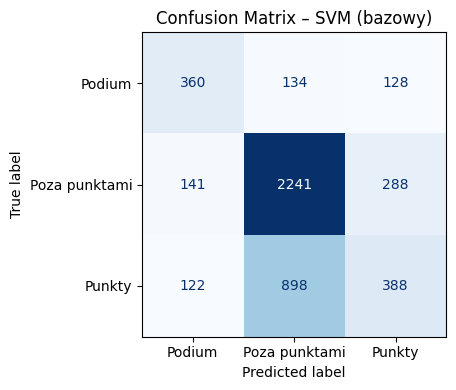

In [7]:
svm_base = SVC(kernel='rbf', random_state=42, probability=True)
svm_base, svm_acc, svm_f1 = evaluate_model(
    'SVM (bazowy)', svm_base,
    X_train_sc, y_train,
    X_test_sc, y_test
)

### 4.2 Kalibracja SVM - GridSearchCV

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Najlepsze parametry SVM: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Najlepsza CV accuracy:   0.6447

=== SVM (po kalibracji) ===
Accuracy:        0.6360
F1 (weighted):   0.6101
CV Accuracy (5): 0.6447
               precision    recall  f1-score   support

       Podium       0.58      0.58      0.58       622
Poza punktami       0.68      0.84      0.75      2670
       Punkty       0.48      0.28      0.35      1408

     accuracy                           0.64      4700
    macro avg       0.58      0.56      0.56      4700
 weighted avg       0.61      0.64      0.61      4700



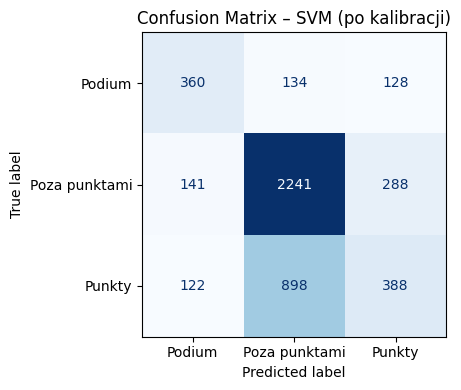

In [8]:
param_grid_svm = {
    'C':      [0.1, 1, 10],
    'gamma':  ['scale', 0.01],
    'kernel': ['rbf']
}
grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(X_train_sc, y_train)
print(f'\nNajlepsze parametry SVM: {grid_svm.best_params_}')
print(f'Najlepsza CV accuracy:   {grid_svm.best_score_:.4f}')
svm_best = grid_svm.best_estimator_
svm_best, svm_acc, svm_f1 = evaluate_model(
    'SVM (po kalibracji)', svm_best,
    X_train_sc, y_train,
    X_test_sc, y_test
)

##  5. Budowa K Nearest Neighbors
### 5.1 Model bazowy + ocena


=== KNN (bazowy) ===
Accuracy:        0.6089
F1 (weighted):   0.5960
CV Accuracy (5): 0.6059
               precision    recall  f1-score   support

       Podium       0.48      0.59      0.53       622
Poza punktami       0.69      0.77      0.73      2670
       Punkty       0.46      0.32      0.38      1408

     accuracy                           0.61      4700
    macro avg       0.54      0.56      0.54      4700
 weighted avg       0.59      0.61      0.60      4700



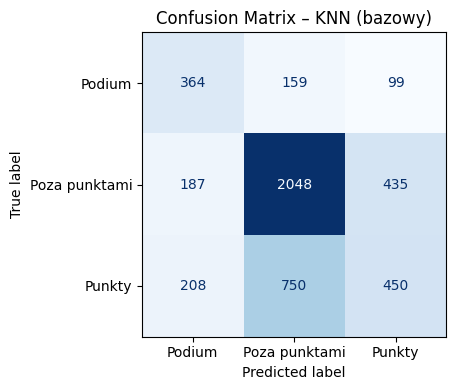

In [9]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base, knn_acc, knn_f1 = evaluate_model(
    'KNN (bazowy)', knn_base,
    X_train_sc, y_train,
    X_test_sc, y_test
)

### 5.2 Kalibracja KNN - GridSearchCV

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Najlepsze parametry KNN: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Najlepsza CV accuracy:   0.6294

=== KNN (po kalibracji) ===
Accuracy:        0.6213
F1 (weighted):   0.6079
CV Accuracy (5): 0.6294
               precision    recall  f1-score   support

       Podium       0.54      0.56      0.55       622
Poza punktami       0.69      0.78      0.73      2670
       Punkty       0.47      0.34      0.39      1408

     accuracy                           0.62      4700
    macro avg       0.57      0.56      0.56      4700
 weighted avg       0.60      0.62      0.61      4700



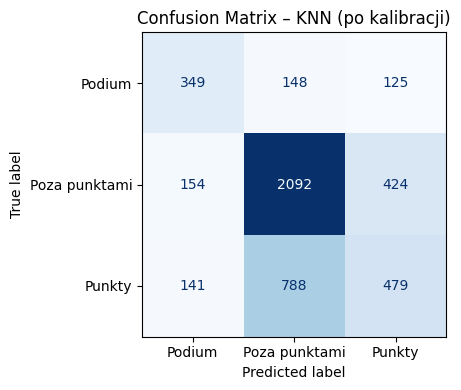

In [10]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan', 'minkowski']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_knn.fit(X_train_sc, y_train)
print(f'\nNajlepsze parametry KNN: {grid_knn.best_params_}')
print(f'Najlepsza CV accuracy:   {grid_knn.best_score_:.4f}')
knn_best = grid_knn.best_estimator_
knn_best, knn_acc, knn_f1 = evaluate_model(
    'KNN (po kalibracji)', knn_best,
    X_train_sc, y_train,
    X_test_sc, y_test
)

##  6. Buodwa MLP
### 6.1 Model bazowy + ocena


=== MLP (bazowy) ===
Accuracy:        0.5983
F1 (weighted):   0.5958
CV Accuracy (5): 0.5991
               precision    recall  f1-score   support

       Podium       0.52      0.58      0.55       622
Poza punktami       0.70      0.71      0.71      2670
       Punkty       0.43      0.39      0.41      1408

     accuracy                           0.60      4700
    macro avg       0.55      0.56      0.55      4700
 weighted avg       0.59      0.60      0.60      4700



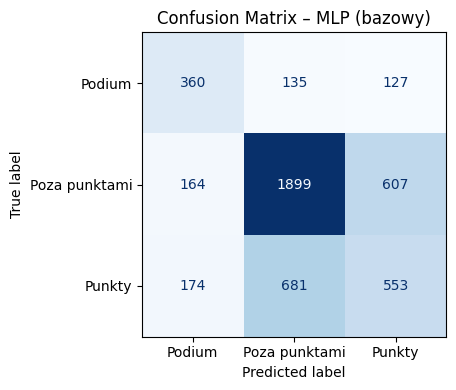

In [11]:
mlp_base = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=1000,
    random_state=42,
)
mlp_base, mlp_acc, mlp_f1 = evaluate_model(
    'MLP (bazowy)', mlp_base,
    X_train_sc, y_train,
    X_test_sc, y_test
)

### 6.2 Kalibracja MLP - GridSearchCV

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Najlepsze parametry MLP: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
Najlepsza CV accuracy:   0.6286

=== MLP (po kalibracji) ===
Accuracy:        0.6255
F1 (weighted):   0.6107
CV Accuracy (5): 0.6286
               precision    recall  f1-score   support

       Podium       0.56      0.59      0.57       622
Poza punktami       0.69      0.79      0.74      2670
       Punkty       0.47      0.33      0.39      1408

     accuracy                           0.63      4700
    macro avg       0.57      0.57      0.57      4700
 weighted avg       0.61      0.63      0.61      4700



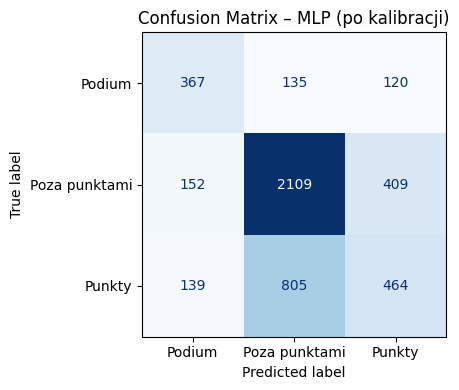

In [12]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
    'activation':         ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha':              [0.0001, 0.001]
}
grid_mlp = GridSearchCV(
    MLPClassifier(max_iter=2000, random_state=42),
    param_grid_mlp,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_mlp.fit(X_train_sc, y_train)
print(f'\nNajlepsze parametry MLP: {grid_mlp.best_params_}')
print(f'Najlepsza CV accuracy:   {grid_mlp.best_score_:.4f}')
mlp_best = grid_mlp.best_estimator_
mlp_best, mlp_acc, mlp_f1 = evaluate_model(
    'MLP (po kalibracji)', mlp_best,
    X_train_sc, y_train,
    X_test_sc, y_test
)

## 7. Porównanie modeli

     Accuracy      F1
RF     0.6370  0.6220
SVM    0.6360  0.6101
KNN    0.6213  0.6079
MLP    0.6255  0.6107


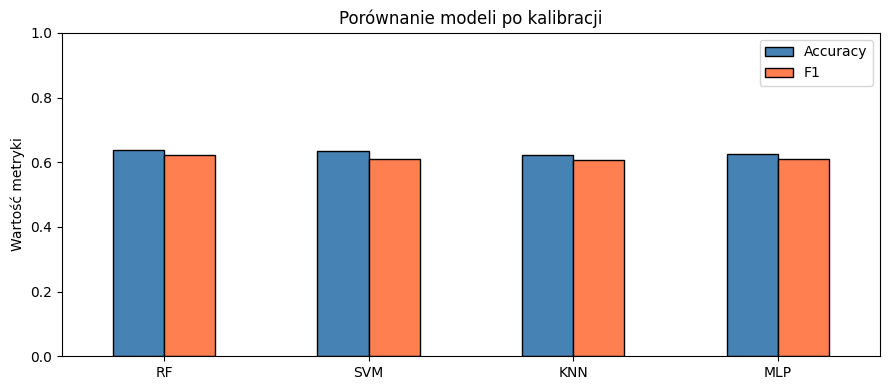

In [13]:
models_summary = {}
for name, model in [('RF', rf_best), ('SVM', svm_best), ('KNN', knn_best), ('MLP', mlp_best)]:
    X_te = X_test if name == 'RF' else X_test_sc
    y_pred = model.predict(X_te)
    models_summary[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1':       f1_score(y_test, y_pred, average='weighted')
    }

summary_df = pd.DataFrame(models_summary).T
print(summary_df.round(4))
summary_df.plot(kind='bar', figsize=(9, 4), edgecolor='black', color=['steelblue', 'coral'])
plt.title('Porównanie modeli po kalibracji')
plt.ylabel('Wartość metryki')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('plots/07_models_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. System ekspercki - VotingClassifier

=== System Ekspercki (VotingClassifier) ===
Accuracy:      0.6379
F1 (weighted): 0.6167
               precision    recall  f1-score   support

       Podium       0.57      0.58      0.58       622
Poza punktami       0.69      0.83      0.75      2670
       Punkty       0.50      0.31      0.38      1408

     accuracy                           0.64      4700
    macro avg       0.59      0.57      0.57      4700
 weighted avg       0.62      0.64      0.62      4700



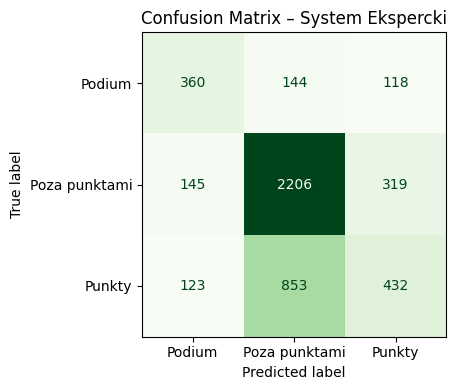

In [14]:
rf_best.fit(X_train_sc, y_train)
expert_system = VotingClassifier(
    estimators=[
        ('rf',  rf_best),
        ('svm', svm_best),
        ('knn', knn_best),
        ('mlp', mlp_best)
    ],
    voting='soft'
)
expert_system.fit(X_train_sc, y_train)
y_pred_expert = expert_system.predict(X_test_sc)
acc_expert    = accuracy_score(y_test, y_pred_expert)
f1_expert     = f1_score(y_test, y_pred_expert, average='weighted')
print(f'=== System Ekspercki (VotingClassifier) ===')
print(f'Accuracy:      {acc_expert:.4f}')
print(f'F1 (weighted): {f1_expert:.4f}')
print(classification_report(y_test, y_pred_expert))
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_expert, ax=ax,
    colorbar=False, cmap='Greens'
)
ax.set_title('Confusion Matrix – System Ekspercki')
plt.tight_layout()
plt.savefig('plots/08_expert_system_cm.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Logika rozmyta - Doradca pit-stopów

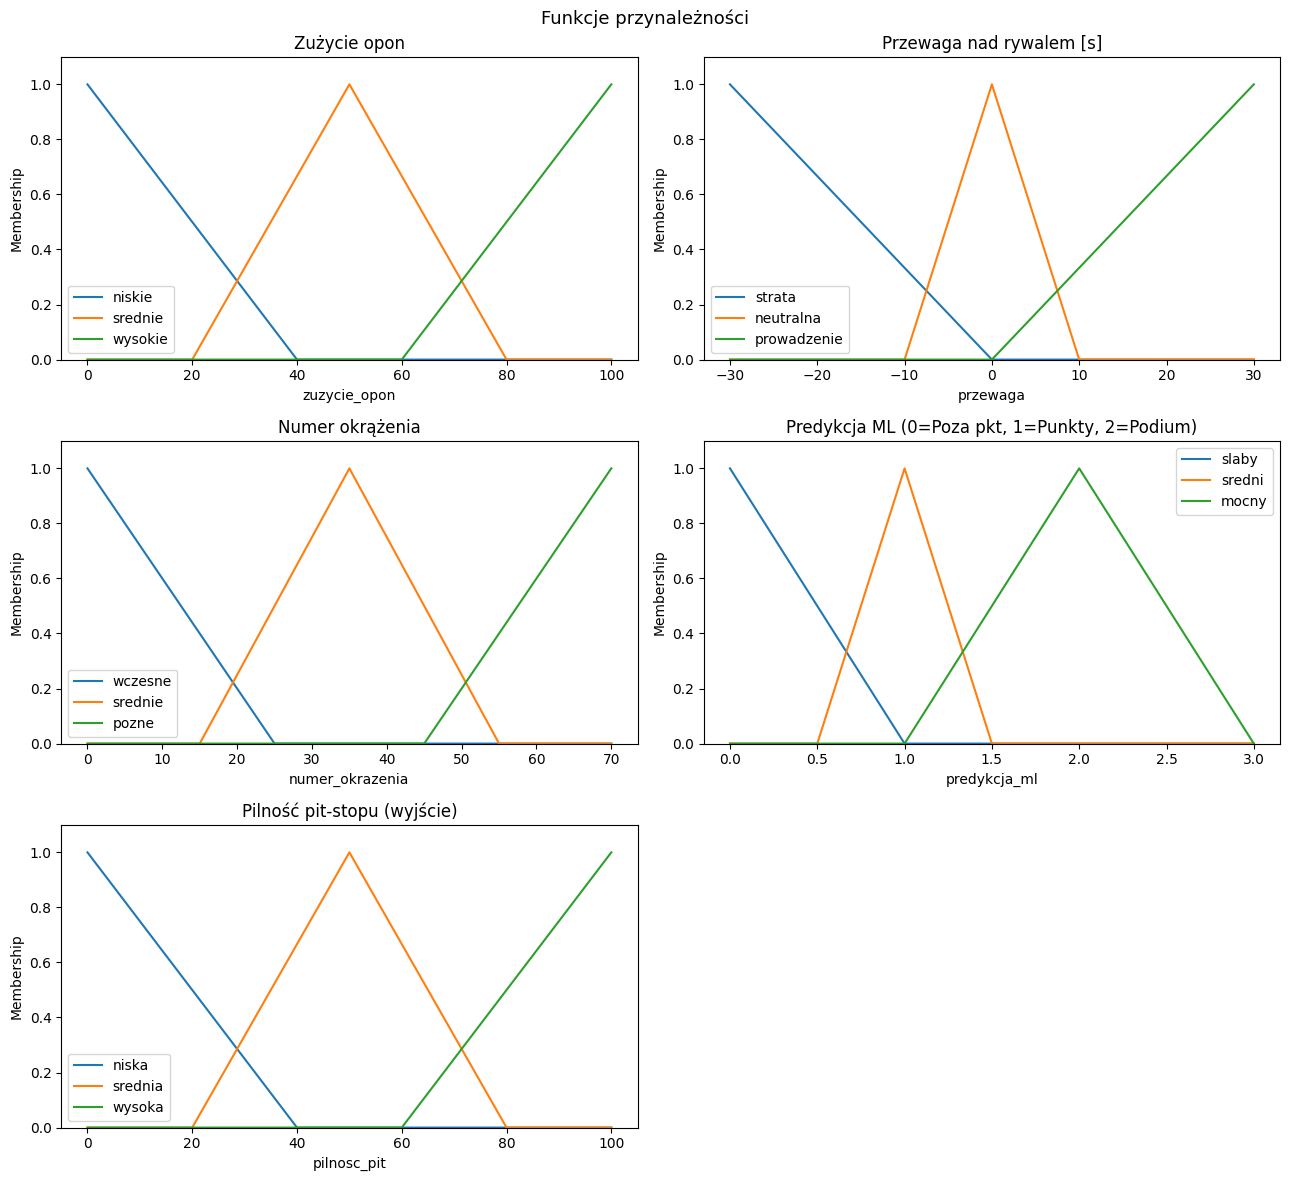

Predykcja systemu eksperckiego: Poza punktami → 0
Pilność pit-stopu: 68.9/100
Rekomendacja: 🔴 PIT


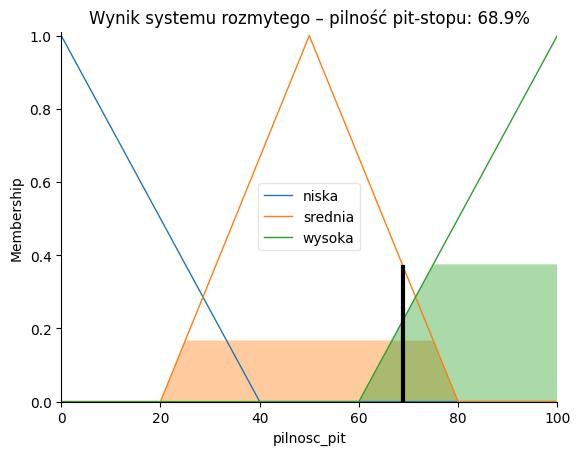

In [15]:
zuzycie_opon    = ctrl.Antecedent(np.arange(0, 101, 1),"zuzycie_opon")
przewaga        = ctrl.Antecedent(np.arange(-30, 31, 1),"przewaga")
numer_okrazenia = ctrl.Antecedent(np.arange(0, 71, 1),"numer_okrazenia")
predykcja_ml    = ctrl.Antecedent(np.arange(0, 3.01, 0.01),  "predykcja_ml")
pilnosc_pit     = ctrl.Consequent(np.arange(0, 101, 1),"pilnosc_pit")

# ── FUNKCJE PRZYNALEŻNOŚCI – ZUŻYCIE OPON ────────────────────────
zuzycie_opon["niskie"]  = fuzz.trimf(zuzycie_opon.universe, [0,   0,  40])
zuzycie_opon["srednie"] = fuzz.trimf(zuzycie_opon.universe, [20, 50,  80])
zuzycie_opon["wysokie"] = fuzz.trimf(zuzycie_opon.universe, [60, 100, 100])

# ── FUNKCJE PRZYNALEŻNOŚCI – PRZEWAGA ────────────────────────────
przewaga["strata"]      = fuzz.trimf(przewaga.universe, [-30, -30,  0])
przewaga["neutralna"]   = fuzz.trimf(przewaga.universe, [-10,   0, 10])
przewaga["prowadzenie"] = fuzz.trimf(przewaga.universe, [  0,  30, 30])

# ── FUNKCJE PRZYNALEŻNOŚCI – NUMER OKRĄŻENIA ─────────────────────
numer_okrazenia["wczesne"] = fuzz.trimf(numer_okrazenia.universe, [0,  0,  25])
numer_okrazenia["srednie"] = fuzz.trimf(numer_okrazenia.universe, [15, 35, 55])
numer_okrazenia["pozne"]   = fuzz.trimf(numer_okrazenia.universe, [45, 70, 70])

# ── FUNKCJE PRZYNALEŻNOŚCI – PREDYKCJA ML ────────────────────────
# 0 = Poza punktami, 1 = Punkty, 2 = Podium
predykcja_ml["slaby"]  = fuzz.trimf(predykcja_ml.universe, [0,   0,   1])
predykcja_ml["sredni"] = fuzz.trimf(predykcja_ml.universe, [0.5, 1, 1.5])
predykcja_ml["mocny"]  = fuzz.trimf(predykcja_ml.universe, [1,   2,   3])

# ── FUNKCJE PRZYNALEŻNOŚCI – PILNOŚĆ PIT-STOPU ───────────────────
pilnosc_pit["niska"]   = fuzz.trimf(pilnosc_pit.universe, [0,   0,  40])
pilnosc_pit["srednia"] = fuzz.trimf(pilnosc_pit.universe, [20, 50,  80])
pilnosc_pit["wysoka"]  = fuzz.trimf(pilnosc_pit.universe, [60, 100, 100])

fig, axes = plt.subplots(3, 2, figsize=(13, 12))

zmienne = [
    (zuzycie_opon,    'Zużycie opon',                                   axes[0, 0]),
    (przewaga,        'Przewaga nad rywalem [s]',                       axes[0, 1]),
    (numer_okrazenia, 'Numer okrążenia',                                axes[1, 0]),
    (predykcja_ml,    'Predykcja ML (0=Poza pkt, 1=Punkty, 2=Podium)', axes[1, 1]),
    (pilnosc_pit,     'Pilność pit-stopu (wyjście)',                    axes[2, 0]),
]
for zmienna, tytul, ax in zmienne:
    for nazwa, mf in zmienna.terms.items():
        ax.plot(zmienna.universe, mf.mf, label=nazwa)
    ax.set_title(tytul)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.set_xlabel(zmienna.label)
    ax.set_ylabel('Membership')

axes[2, 1].axis('off')
plt.suptitle('Funkcje przynależności', fontsize=13)
plt.tight_layout()
plt.savefig('plots/09_fuzzy_membership.png', dpi=120, bbox_inches='tight')
plt.show()

# ── MAPOWANIE PREDYKCJI ML NA LICZBĘ ────────────────────────────
# System rozmyty operuje na liczbach, więc mapujemy klasy
klasa_na_liczbe = {"Poza punktami": 0, "Punkty": 1, "Podium": 2}

rules = [
    # Reguła 1: Opony bardzo zużyte -> pit
    ctrl.Rule(zuzycie_opon["wysokie"], pilnosc_pit["wysoka"]),
    # Reguła 2: Opony świeże + 1-miejsce -> zostań
    ctrl.Rule(zuzycie_opon["niskie"] & przewaga["prowadzenie"], pilnosc_pit["niska"]),
    # Reguła 3: Środkowe okrążenia + średnie zużycie -> być może pit
    ctrl.Rule(numer_okrazenia["srednie"] & zuzycie_opon["srednie"], pilnosc_pit["srednia"]),
    # Reguła 4: Poza punktami + późne okrążenia -> pit
    ctrl.Rule(przewaga["strata"] & numer_okrazenia["pozne"], pilnosc_pit["wysoka"]),
    # Reguła 5: Wczesne okrążenia -> nie pit
    ctrl.Rule(numer_okrazenia["wczesne"], pilnosc_pit["niska"]),
    # Reguła 6: Średnie zużycie + strata -> rozważ pit
    ctrl.Rule(zuzycie_opon["srednie"] & przewaga["strata"], pilnosc_pit["srednia"]),
    # Reguła 7: Prowadzenie + późne okrążenia + średnie zużycie -> być może pit
    ctrl.Rule(przewaga["prowadzenie"] & numer_okrazenia["pozne"] & zuzycie_opon["srednie"], pilnosc_pit["srednia"]),
    
    # Reguła 8: Modele przewidują słaby wynik + średnie zużycie -> pit
    ctrl.Rule(predykcja_ml["slaby"] & zuzycie_opon["srednie"], pilnosc_pit["wysoka"]),
    # Reguła 9: Modele przewidują podium + prowadzenie -> nie pit
    ctrl.Rule(predykcja_ml["mocny"] & przewaga["prowadzenie"], pilnosc_pit["niska"]),
    # Reguła 10: Modele przewidują podium + średnie zużycie -> być może pit
    ctrl.Rule(predykcja_ml["mocny"] & zuzycie_opon["srednie"], pilnosc_pit["niska"]),
    # Reguła 11: Modele niepewne (Punkty) + wysokie zużycie -> pit
    ctrl.Rule(predykcja_ml["sredni"] & zuzycie_opon["wysokie"], pilnosc_pit["wysoka"]),
    # Reguła 12: Modele niepewne (Punkty) + niskie zużycie -> nie pit
    ctrl.Rule(predykcja_ml["sredni"] & zuzycie_opon["niskie"], pilnosc_pit["niska"]),
]
# ── SILNIK WNIOSKOWANIA ────────────────────────────────────────────
pit_ctrl = ctrl.ControlSystem(rules)
pit_sim  = ctrl.ControlSystemSimulation(pit_ctrl)

# ── TEST Z PREDYKCJĄ SYSTEMU EKSPERCKIEGO ────────────────────────
# Pobieramy predykcję VotingClassifier dla przykładowego wiersza z danych testowych
przyklad      = X_test_sc[0].reshape(1, -1)
predykcja_str = expert_system.predict(przyklad)[0]
predykcja_num = klasa_na_liczbe[predykcja_str]
print(f"Predykcja systemu eksperckiego: {predykcja_str} → {predykcja_num}")

# Scenariusz: okrążenie 40/70, opony 75% zużyte, 5s za rywalem
pit_sim.input["zuzycie_opon"]    = 75
pit_sim.input["przewaga"]        = -5
pit_sim.input["numer_okrazenia"] = 40
pit_sim.input["predykcja_ml"]    = predykcja_num
pit_sim.compute()

wynik = pit_sim.output["pilnosc_pit"]
print(f"Pilność pit-stopu: {wynik:.1f}/100")
if wynik >= 65:
    rekomendacja = "🔴 PIT"
elif wynik >= 35:
    rekomendacja = "🟡 Rozważ pit-stop"
else:
    rekomendacja = "🟢 Zostań na torze"
print(f"Rekomendacja: {rekomendacja}")

# Wizualizacja wyniku rozmytego (zagregowany obszar aktywny)
pilnosc_pit.view(sim=pit_sim)
plt.title(f'Wynik systemu rozmytego – pilność pit-stopu: {wynik:.1f}%')
plt.savefig('plots/10_fuzzy_output.png', dpi=120, bbox_inches='tight')
plt.show()

